In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

c:\Users\Kiran\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 2.44M/2.44M [00:01<00:00, 1.61MB/s]

Extracting files...
Path to dataset files: C:\Users\Kiran\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3


In [2]:
import os
import numpy
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
file_path =os.path.join(path, "AB_NYC_2019.csv")
df = pd.read_csv(file_path)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [8]:
df.duplicated()
df.drop_duplicates(inplace=True)
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

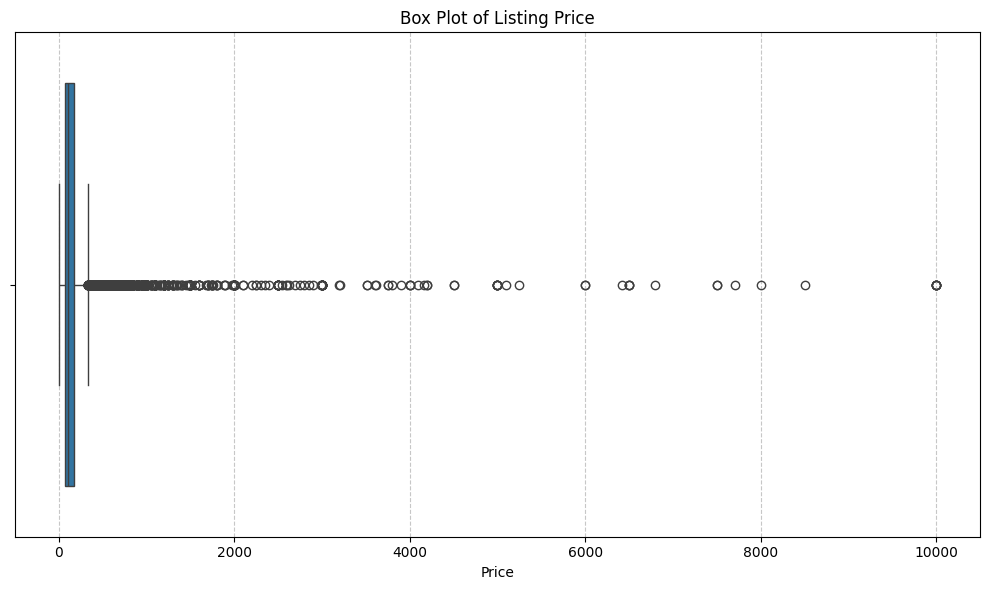

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['price'])
plt.title('Box Plot of Listing Price')
plt.xlabel('Price')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

print(f"Q1 (25th percentile) for Price: {Q1_price}")
print(f"Q3 (75th percentile) for Price: {Q3_price}")
print(f"IQR for Price: {IQR_price}")
print(f"Lower Bound for Price Outliers: {lower_bound_price}")
print(f"Upper Bound for Price Outliers: {upper_bound_price}")

num_outliers_price = df[(df['price'] < lower_bound_price) | (df['price'] > upper_bound_price)].shape[0]
print(f"Number of price outliers: {num_outliers_price}")
print(f"Percentage of price outliers: {num_outliers_price / len(df) * 100:.2f}%")

Q1 (25th percentile) for Price: 69.0
Q3 (75th percentile) for Price: 175.0
IQR for Price: 106.0
Lower Bound for Price Outliers: -90.0
Upper Bound for Price Outliers: 334.0
Number of price outliers: 2972
Percentage of price outliers: 6.08%


Price outliers capped. New descriptive statistics for price:
count    48895.000000
mean       132.979978
std         83.530147
min          1.000000
25%         69.000000
50%        106.000000
75%        175.000000
max        334.000000
Name: price, dtype: float64


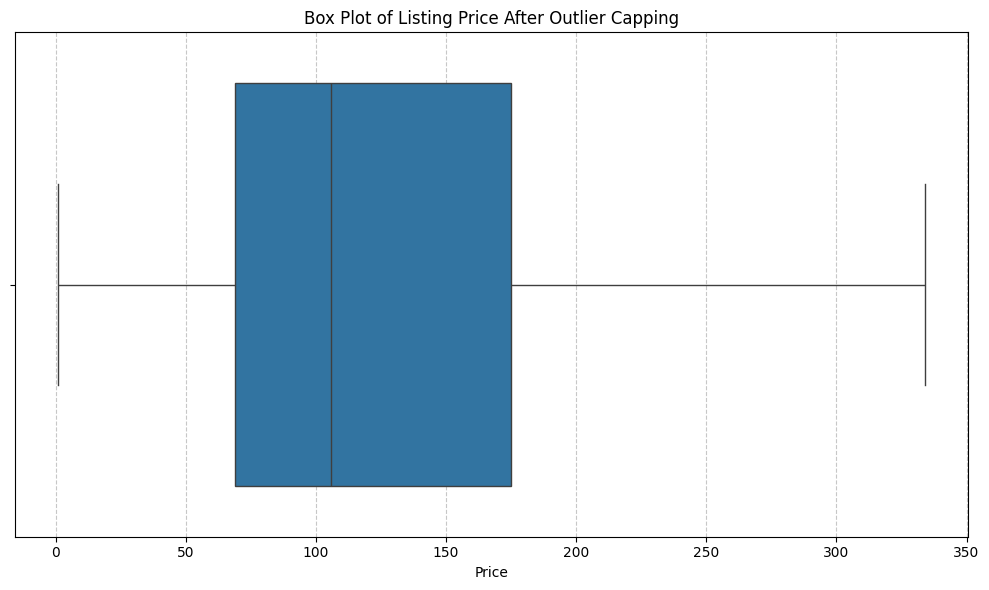

In [12]:
# Cap prices above the upper bound
import numpy as np


df['price'] = np.where(df['price'] > upper_bound_price, upper_bound_price, df['price'])
# Cap prices below a reasonable minimum (e.g., 1 dollar), assuming 0 dollar listings are data errors
df['price'] = np.where(df['price'] < 1, 1, df['price'])

print("Price outliers capped. New descriptive statistics for price:")
print(df['price'].describe())

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['price'])
plt.title('Box Plot of Listing Price After Outlier Capping')
plt.xlabel('Price')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\Kiran\AppData\Local\Temp\ipykernel_23700\100341331.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='neighbourhood_group', data=df, palette='viridis')


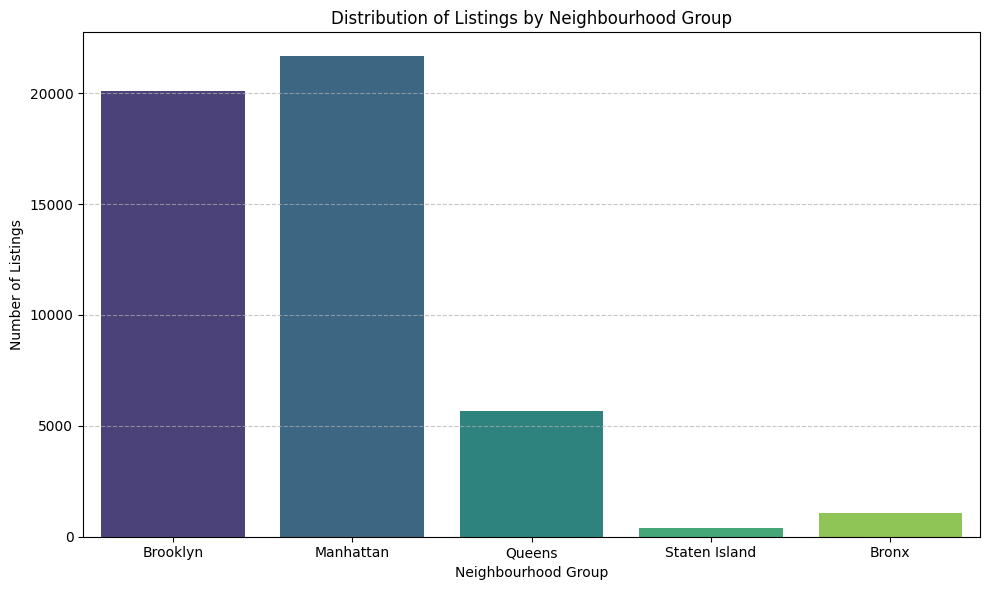

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(x='neighbourhood_group', data=df, palette='viridis')
plt.title('Distribution of Listings by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\Kiran\AppData\Local\Temp\ipykernel_23700\4116276200.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='neighbourhood_group', y='price', data=df, palette='viridis')


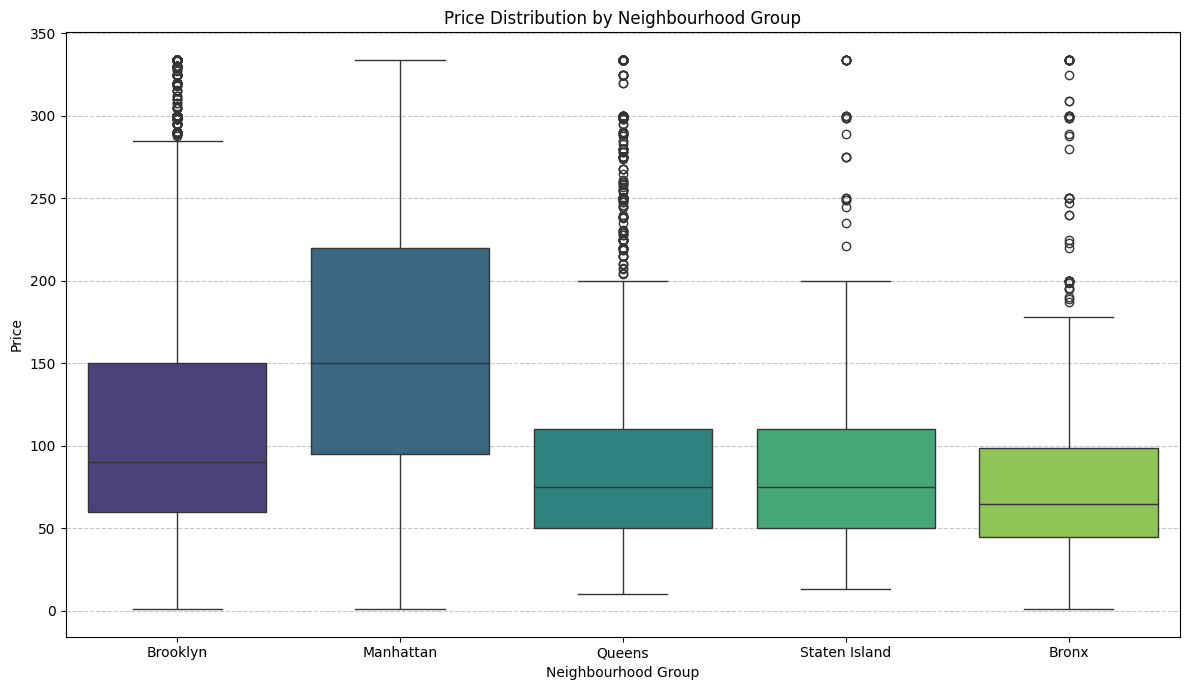

In [14]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='neighbourhood_group', y='price', data=df, palette='viridis')
plt.title('Price Distribution by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

DATASET-2 in data cleaning 

In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datasnaek/youtube-new")

print("Path to dataset files:", path)

100%|██████████| 201M/201M [02:52<00:00, 1.22MB/s] 

Extracting files...


Path to dataset files: C:\Users\Kiran\.cache\kagglehub\datasets\datasnaek\youtube-new\versions\115


In [16]:
import os
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt 

In [21]:
file_path = os.path.join(path, "USvideos.csv")
df= pd.read_csv(file_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  40949 non-null  bool  
 15  de

In [22]:
# Missing Data Handling: Check for null values in each column
print("Missing values summary:")
print(df.isnull().sum())

# Duplicate Removal: Check for and count duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

if duplicates > 0:
    # Removing duplicates to maintain data uniqueness
    df = df.drop_duplicates()
    print("Duplicates removed successfully.")

Missing values summary:
video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               570
dtype: int64

Number of duplicate rows: 48
Duplicates removed successfully.


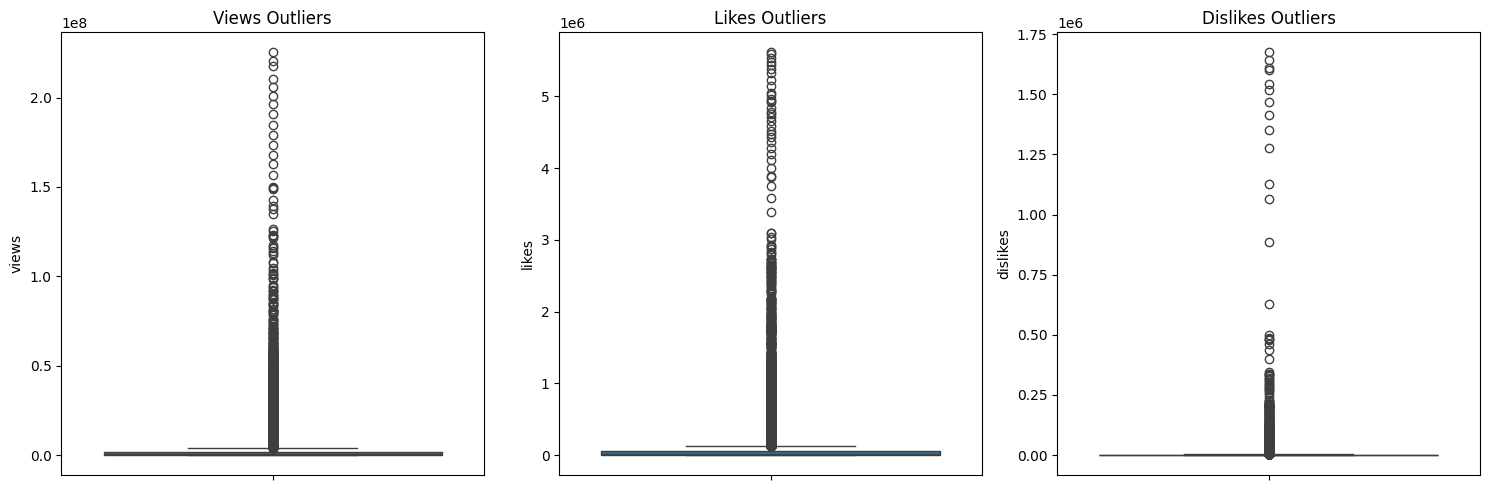

Numerical Statistics Summary:
              views         likes      dislikes
count  4.090100e+04  4.090100e+04  4.090100e+04
mean   2.360678e+06  7.427173e+04  3.711722e+03
std    7.397719e+06  2.289999e+05  2.904624e+04
min    5.490000e+02  0.000000e+00  0.000000e+00
25%    2.419720e+05  5.416000e+03  2.020000e+02
50%    6.810640e+05  1.806900e+04  6.300000e+02
75%    1.821926e+06  5.533800e+04  1.936000e+03
max    2.252119e+08  5.613827e+06  1.674420e+06


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize outliers in numerical columns
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['views'])
plt.title('Views Outliers')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['likes'])
plt.title('Likes Outliers')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['dislikes'])
plt.title('Dislikes Outliers')

plt.tight_layout()
plt.show()

# Calculate basic statistics to quantify the scale
print("Numerical Statistics Summary:")
print(df[['views', 'likes', 'dislikes']].describe())

In [24]:
# Standardize 'trending_date' from 'YY.DD.MM' to datetime objects
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')

# Standardize 'publish_time' to datetime objects (handling ISO 8601 format)
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')

# Verify the changes
print("Data types after standardization:")
print(df[['trending_date', 'publish_time']].dtypes)
display(df[['trending_date', 'publish_time']].head())

Data types after standardization:
trending_date         datetime64[ns]
publish_time     datetime64[ns, UTC]
dtype: object


,trending_date,publish_time
0,2017-11-14,2017-11-13 17:13:01+00:00
1,2017-11-14,2017-11-13 07:30:00+00:00
2,2017-11-14,2017-11-12 19:05:24+00:00
3,2017-11-14,2017-11-13 11:00:04+00:00
4,2017-11-14,2017-11-12 18:01:41+00:00


outlier detection 

In [26]:
cols = ['views', 'likes', 'dislikes']
outlier_summary = []

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100
    
    outlier_summary.append({
        'Metric': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Upper Bound': upper_bound,
        'Outlier Count': outlier_count,
        'Outlier %': f"{outlier_percentage:.2f}%"
    })

df_outliers = pd.DataFrame(outlier_summary)
display(df_outliers)

,Metric,Q1,Q3,IQR,Upper Bound,Outlier Count,Outlier %
0,views,241972.0,1821926.0,1579954.0,4191857.0,4497,10.99%
1,likes,5416.0,55338.0,49922.0,130221.0,5137,12.56%
2,dislikes,202.0,1936.0,1734.0,4537.0,5282,12.91%


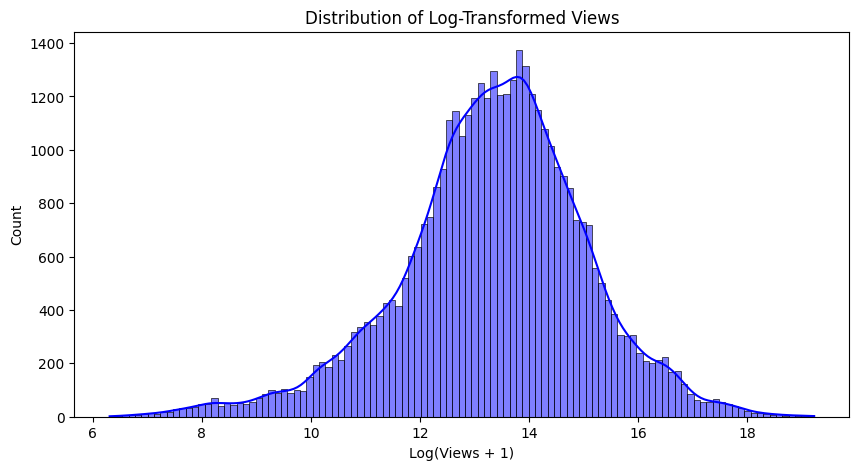

Log transformation applied to views, likes, and dislikes.


,views,views_log,likes,likes_log,dislikes,dislikes_log
0,748374,13.525659,57527,10.960027,2966,7.995307
1,2418783,14.698775,97185,11.484382,6146,8.723719
2,3191434,14.975981,146033,11.891595,5339,8.582981
3,343168,12.745978,10172,9.227492,666,6.502790
4,2095731,14.555413,132235,11.792343,1989,7.595890


In [27]:
import numpy as np

# Apply log transformation to reduce the skewness of outliers identified in df_outliers
for col in ['views', 'likes', 'dislikes']:
    df[f'{col}_log'] = np.log1p(df[col])

# Visualize the new distribution for views
plt.figure(figsize=(10, 5))
sns.histplot(df['views_log'], kde=True, color='blue')
plt.title('Distribution of Log-Transformed Views')
plt.xlabel('Log(Views + 1)')
plt.show()

print("Log transformation applied to views, likes, and dislikes.")
display(df[['views', 'views_log', 'likes', 'likes_log', 'dislikes', 'dislikes_log']].head())

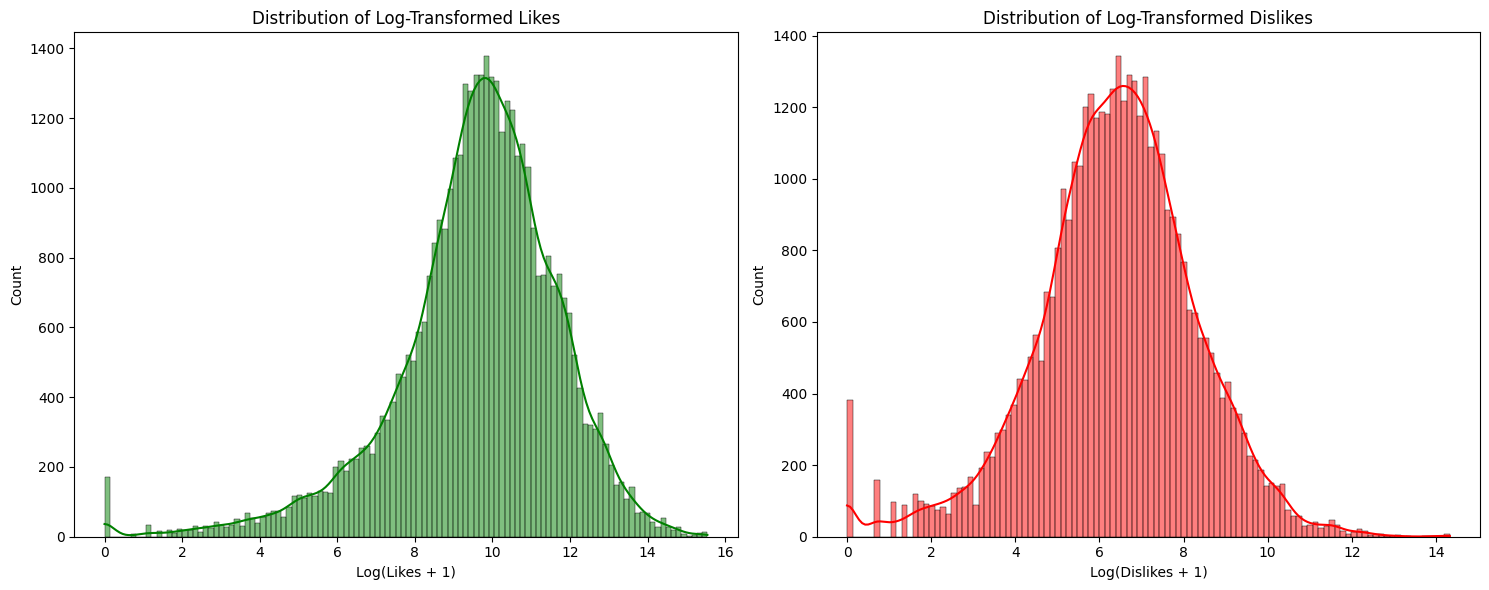

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
plt.figure(figsize=(15, 6))

# Plot distribution for Log-Transformed Likes
plt.subplot(1, 2, 1)
sns.histplot(df['likes_log'], kde=True, color='green')
plt.title('Distribution of Log-Transformed Likes')
plt.xlabel('Log(Likes + 1)')

# Plot distribution for Log-Transformed Dislikes
plt.subplot(1, 2, 2)
sns.histplot(df['dislikes_log'], kde=True, color='red')
plt.title('Distribution of Log-Transformed Dislikes')
plt.xlabel('Log(Dislikes + 1)')

plt.tight_layout()
plt.show()